# Fundamentos de Ciencias de la Computación

Este notebook cubre los conceptos centrales, desde los fundamentos matemáticos de la computación hasta la arquitectura de hardware, lenguajes de programación, paradigmas, estructuras de datos y compiladores.


---
## 1. Fundamentos Teóricos de la Computación

### 1.1 Definición Formal de Algoritmo

Un **algoritmo** es una secuencia finita, determinista y efectiva de instrucciones
que resuelve un problema en un número finito de pasos.

#### Definición (Church-Turing)

Una función $f: \Sigma^* \to \Sigma^*$ es **computable** si y solo si existe una
Máquina de Turing que la calcula. Todo algoritmo formalizable corresponde a
una función computable.

#### Propiedades de un algoritmo

| Propiedad | Descripción |
|-----------|-------------|
| **Finititud** | Termina en número finito de pasos |
| **Definitud** | Cada instrucción es precisa y no ambigua |
| **Entrada** | $\geq 0$ entradas de un conjunto especificado |
| **Salida** | $\geq 1$ salidas relacionadas con las entradas |
| **Efectividad** | Cada paso es suficientemente básico para ser ejecutado exactamente |

#### Complejidad: recursos que consume un algoritmo

Dado un algoritmo $A$ y una entrada de tamaño $n$, definimos:

$$T_A(n) = \text{número de operaciones elementales en el peor caso}$$
$$S_A(n) = \text{celdas de memoria adicionales usadas}$$

### 1.2 Notación Asintótica

La notación asintótica describe el **comportamiento límite** de una función cuando
$n \to \infty$, ignorando constantes multiplicativas.

#### Big-$O$ — Cota superior

$$f(n) = O(g(n)) \iff \exists\, c > 0,\, n_0 \in \mathbb{N} :\; f(n) \leq c\cdot g(n)\quad \forall n \geq n_0$$

#### Big-$\Omega$ — Cota inferior

$$f(n) = \Omega(g(n)) \iff \exists\, c > 0,\, n_0 :\; f(n) \geq c\cdot g(n)\quad \forall n \geq n_0$$

#### Big-$\Theta$ — Cota ajustada

$$f(n) = \Theta(g(n)) \iff f(n) = O(g(n)) \text{ y } f(n) = \Omega(g(n))$$

#### Reglas de cálculo

1. **Constantes**: $O(c \cdot f) = O(f)$
2. **Suma**: $O(f + g) = O(\max(f, g))$
3. **Producto**: $O(f \cdot g) = O(f) \cdot O(g)$
4. **Logaritmos**: $O(\log_a n) = O(\log_b n)$ para $a,b > 1$

#### Ejemplo paso a paso

Analizar $T(n) = 5n^3 + 3n^2 \log n + 42n - 7$:

$$T(n) \leq 5n^3 + 3n^3 + 42n^3 - 7 = 50n^3 \quad \forall n \geq 1$$

Tomando $c = 50$, $n_0 = 1$: $T(n) = O(n^3)$

Adicionalmente $T(n) \geq 5n^3$, tomando $c = 5$: $T(n) = \Omega(n^3)$

Por tanto: $T(n) = \Theta(n^3)$

#### Jerarquía de clases de complejidad comunes

$$O(1) \subset O(\log n) \subset O(\sqrt{n}) \subset O(n) \subset O(n \log n) \subset O(n^2) \subset O(2^n) \subset O(n!)$$

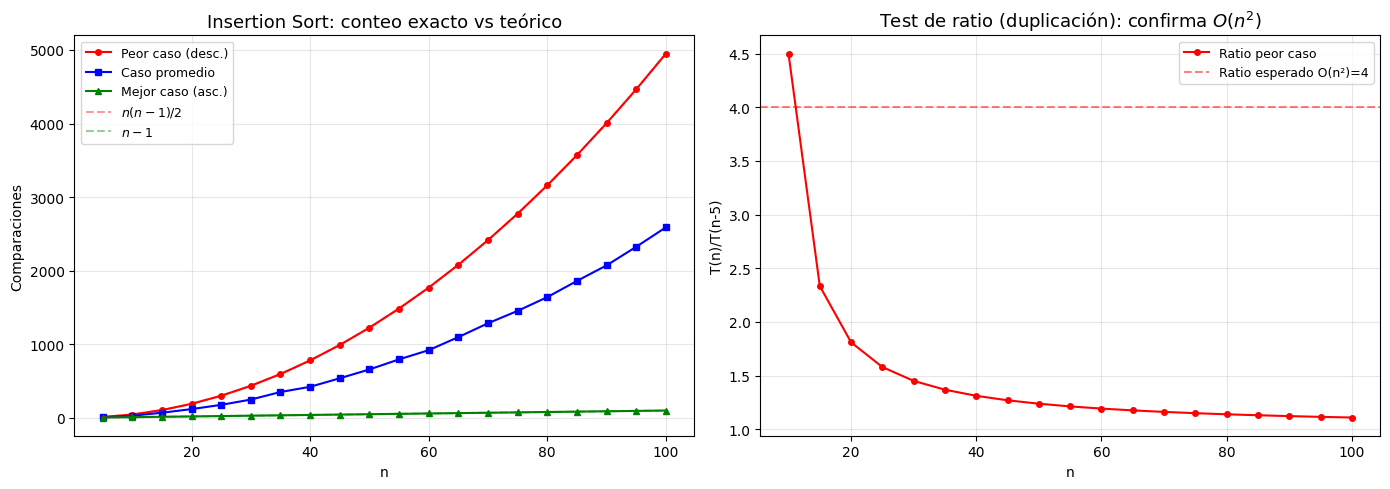

In [18]:
import numpy as np
import matplotlib.pyplot as plt

def count_ops_insertion_sort(arr):
    # Returns (sorted array, exact comparison count)
    a = arr.copy()
    comparisons = 0
    for i in range(1, len(a)):
        key = a[i]
        j = i - 1
        while j >= 0:
            comparisons += 1
            if a[j] > key:
                a[j+1] = a[j]
                j -= 1
            else:
                break
        a[j+1] = key
    return a, comparisons

# Measure empirically
sizes = list(range(5, 101, 5))
worst_ops, best_ops, avg_ops = [], [], []

for n in sizes:
    # Worst: reverse sorted
    _, wc = count_ops_insertion_sort(list(range(n, 0, -1)))
    worst_ops.append(wc)
    # Best: already sorted
    _, bc = count_ops_insertion_sort(list(range(n)))
    best_ops.append(bc)
    # Average: random
    trials = [count_ops_insertion_sort(list(np.random.permutation(n)))[1] for _ in range(20)]
    avg_ops.append(np.mean(trials))

ns = np.array(sizes)
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(sizes, worst_ops, 'r-o', ms=4, label='Peor caso (desc.)')
axes[0].plot(sizes, avg_ops,   'b-s', ms=4, label='Caso promedio')
axes[0].plot(sizes, best_ops,  'g-^', ms=4, label='Mejor caso (asc.)')
axes[0].plot(ns, ns*(ns-1)/2, 'r--', alpha=0.4, label=r'$n(n-1)/2$')
axes[0].plot(ns, ns-1,        'g--', alpha=0.4, label=r'$n-1$')
axes[0].set_xlabel('n'); axes[0].set_ylabel('Comparaciones')
axes[0].set_title('Insertion Sort: conteo exacto vs teórico', fontsize=13)
axes[0].legend(fontsize=9); axes[0].grid(True, alpha=0.3)

# Ratio doubling test: if O(n^k), ratio ~ 2^k
ratios_worst = [worst_ops[i+1]/worst_ops[i] for i in range(len(worst_ops)-1)
                if worst_ops[i] > 0]
axes[1].plot(sizes[1:], ratios_worst, 'r-o', ms=4, label='Ratio peor caso')
axes[1].axhline(y=4, color='red', linestyle='--', alpha=0.5, label='Ratio esperado O(n²)=4')
axes[1].set_xlabel('n'); axes[1].set_ylabel('T(n)/T(n-5)')
axes[1].set_title('Test de ratio (duplicación): confirma $O(n^2)$', fontsize=13)
axes[1].legend(fontsize=9); axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

### 1.3 Computabilidad: Problemas Computables y No Computables

#### Tesis de Church-Turing

> *Todo proceso que intuitivamente llamaríamos "cómputo efectivo" puede ser
> realizado por una Máquina de Turing.*

#### Problema de la Parada (*Halting Problem*)

**Enunciado**: ¿Existe un algoritmo $H(P, I)$ que, dado cualquier programa $P$
y entrada $I$, decide si $P$ termina en $I$?

**Teorema** (Turing, 1936): El problema de la parada es **indecidible**.

**Demostración** (por contradicción):

Supongamos que existe $H(P, I)$ que retorna `True` si $P$ para en $I$, `False` si no.
Construimos $D(P)$:
```
def D(P):
    if H(P, P) == True:   # P para cuando se da como entrada a sí mismo
        while True: pass  # D entra en ciclo infinito
    else:
        return            # D termina
```
Evaluamos $D(D)$:
- Si $H(D,D) = $ True → $D(D)$ cicla → $H$ estaba equivocado.
- Si $H(D,D) = $ False → $D(D)$ termina → $H$ estaba equivocado.

Contradicción. $\therefore$ $H$ no puede existir. $\blacksquare$

#### Jerarquía de decidibilidad

```
┌─────────────────────────────────────────────────────┐
│  Todos los lenguajes                                │
│  ┌───────────────────────────────────────────────┐  │
│  │  Reconocibles (semidecidibles / RE)           │  │
│  │  ┌─────────────────────────────────────────┐  │  │
│  │  │  Decidibles (recursivos)                │  │  │
│  │  │  ┌───────────────────────────────────┐  │  │  │
│  │  │  │  Contexto libre (CFLs)            │  │  │  │
│  │  │  │  ┌─────────────────────────────┐  │  │  │  │
│  │  │  │  │  Regulares (DFA/NFA/RegEx) │   │  │  │  │
│  │  │  │  └─────────────────────────────┘  │  │  │  │
│  │  │  └───────────────────────────────────┘  │  │  │
│  │  └─────────────────────────────────────────┘  │  │
│  └───────────────────────────────────────────────┘  │
└─────────────────────────────────────────────────────┘
```

| Clase | Reconocedor | Ejemplo |
|-------|-------------|--------|
| Regular | DFA / NFA | `a*b+`, identificadores |
| Libre de contexto | PDA | Expresiones aritméticas, XML |
| Decidible | MT que siempre para | Todos los algoritmos |
| RE | MT (puede no parar) | Lenguaje de parada |
| No RE | Ningún reconocedor | Complemento del problema de parada |

### 1.4 Máquina de Turing

#### Definición formal

Una **Máquina de Turing determinista** es una 7-tupla:

$$M = (Q, \Sigma, \Gamma, \delta, q_0, q_{\text{accept}}, q_{\text{reject}})$$

donde:

| Símbolo | Significado |
|---------|-------------|
| $Q$ | Conjunto finito de **estados** |
| $\Sigma$ | **Alfabeto de entrada** (no contiene el blanco $\sqcup$) |
| $\Gamma$ | **Alfabeto de cinta** ($\Sigma \subseteq \Gamma$, $\sqcup \in \Gamma$) |
| $\delta: Q \times \Gamma \to Q \times \Gamma \times \{L, R\}$ | **Función de transición** |
| $q_0 \in Q$ | Estado inicial |
| $q_{\text{accept}} \in Q$ | Estado de aceptación |
| $q_{\text{reject}} \in Q$ | Estado de rechazo |

#### Funcionamiento

En cada paso la MT:
1. Lee el símbolo bajo el cabezal
2. Aplica $\delta$ para obtener nuevo estado, símbolo a escribir y dirección
3. Escribe el símbolo, mueve el cabezal y cambia de estado

#### Configuración

Una **configuración** es una tripleta $(q, w, i)$: estado $q$, contenido de cinta $w$,
posición del cabezal $i$. Se denota $uqv$ donde $u$ es lo que está a la izquierda
y $v$ a la derecha del cabezal.

In [19]:
# Simulador de Máquina de Turing
# Ejemplo: reconocer el lenguaje 0^n 1^n (n >= 1)

class TuringMachine:
    def __init__(self, states, sigma, gamma, delta, q0, q_accept, q_reject, blank='_'):
        self.states = states
        self.sigma = sigma
        self.gamma = gamma
        self.delta = delta     # dict: (state, symbol) -> (new_state, write, direction)
        self.q0 = q0
        self.q_accept = q_accept
        self.q_reject = q_reject
        self.blank = blank

    def run(self, input_str, verbose=True, max_steps=1000):
        tape = list(input_str) + [self.blank] * 10
        head = 0
        state = self.q0
        steps = 0
        if verbose:
            print(f'Entrada: "{input_str}"')
            print(f'{"Paso":>4} | {"Estado":>8} | Cinta (cabezal=^)')
            print('-' * 55)

        while state not in (self.q_accept, self.q_reject) and steps < max_steps:
            sym = tape[head] if head < len(tape) else self.blank
            key = (state, sym)

            if verbose and steps < 25:
                tape_str = ''.join(tape[:max(head+3, 8)]).rstrip(self.blank)
                marked = tape_str[:head] + '[' + (tape_str[head] if head < len(tape_str) else '_') + ']' + tape_str[head+1:]
                print(f'{steps:>4} | {state:>8} | {marked}')

            if key not in self.delta:
                state = self.q_reject
                break

            new_state, write_sym, direction = self.delta[key]
            while head >= len(tape): tape.append(self.blank)
            tape[head] = write_sym
            head += 1 if direction == 'R' else -1
            if head < 0: head = 0
            state = new_state
            steps += 1

        result = 'ACEPTA' if state == self.q_accept else 'RECHAZA'
        if verbose:
            print(f'\nResultado: {result} (pasos: {steps})')
        return state == self.q_accept

# MT para L = {0^n 1^n | n >= 1}
# Estrategia: marcar un 0 con X, luego buscar un 1 y marcarlo con Y
# Repetir hasta que no queden 0s ni 1s sin marcar
delta_01n = {
    ('q0', '0'): ('q1', 'X', 'R'),   # marcar primer 0 como X, buscar 1
    ('q1', '0'): ('q1', '0', 'R'),   # saltar 0s no marcados
    ('q1', 'Y'): ('q1', 'Y', 'R'),   # saltar Ys ya marcadas
    ('q1', '1'): ('q2', 'Y', 'L'),   # marcar primer 1 como Y, volver
    ('q2', '0'): ('q2', '0', 'L'),   # volver a la izquierda
    ('q2', 'Y'): ('q2', 'Y', 'L'),
    ('q2', 'X'): ('q0', 'X', 'R'),   # llegamos a X, repetir
    ('q0', 'Y'): ('q3', 'Y', 'R'),   # no quedan 0s, verificar que no haya 1s
    ('q3', 'Y'): ('q3', 'Y', 'R'),
    ('q3', '_'): ('qA', '_', 'R'),   # solo Ys y blancos: aceptar
}

mt = TuringMachine(
    states={'q0','q1','q2','q3','qA','qR'},
    sigma={'0','1'}, gamma={'0','1','X','Y','_'},
    delta=delta_01n, q0='q0', q_accept='qA', q_reject='qR'
)

print('=== Caso 1: 0011 (debería ACEPTAR) ===')
mt.run('0011', verbose=True)
print()
print('=== Caso 2: 000111 (debería ACEPTAR) ===')
mt.run('000111', verbose=False)
print(f'  Resultado: {"ACEPTA" if mt.run("000111", verbose=False) else "RECHAZA"}')
print('=== Caso 3: 001 (debería RECHAZAR) ===')
print(f'  Resultado: {"ACEPTA" if mt.run("001", verbose=False) else "RECHAZA"}')
print('=== Caso 4: 0000 (debería RECHAZAR) ===')
print(f'  Resultado: {"ACEPTA" if mt.run("0000", verbose=False) else "RECHAZA"}')

=== Caso 1: 0011 (debería ACEPTAR) ===
Entrada: "0011"
Paso |   Estado | Cinta (cabezal=^)
-------------------------------------------------------
   0 |       q0 | [0]011
   1 |       q1 | X[0]11
   2 |       q1 | X0[1]1
   3 |       q2 | X[0]Y1
   4 |       q2 | [X]0Y1
   5 |       q0 | X[0]Y1
   6 |       q1 | XX[Y]1
   7 |       q1 | XXY[1]
   8 |       q2 | XX[Y]Y
   9 |       q2 | X[X]YY
  10 |       q0 | XX[Y]Y
  11 |       q3 | XXY[Y]
  12 |       q3 | XXYY[_]

Resultado: ACEPTA (pasos: 13)

=== Caso 2: 000111 (debería ACEPTAR) ===
  Resultado: ACEPTA
=== Caso 3: 001 (debería RECHAZAR) ===
  Resultado: RECHAZA
=== Caso 4: 0000 (debería RECHAZAR) ===
  Resultado: RECHAZA


### 1.5 Lenguajes Formales y Autómatas

#### Lenguaje formal

Dado un alfabeto finito $\Sigma$, un **lenguaje** $L \subseteq \Sigma^*$ es cualquier
conjunto de cadenas sobre $\Sigma$.

#### Autómata Finito Determinista (DFA)

Un DFA es una 5-tupla $A = (Q, \Sigma, \delta, q_0, F)$:

| Símbolo | Significado |
|---------|-------------|
| $Q$ | Conjunto finito de estados |
| $\Sigma$ | Alfabeto |
| $\delta: Q \times \Sigma \to Q$ | Función de transición |
| $q_0 \in Q$ | Estado inicial |
| $F \subseteq Q$ | Estados de aceptación |

$A$ **acepta** una cadena $w = a_1 a_2 \cdots a_n$ si existe una secuencia
$r_0, r_1, \ldots, r_n$ tal que:

$$r_0 = q_0, \quad r_{i+1} = \delta(r_i, a_{i+1}), \quad r_n \in F$$

#### Expresiones regulares ↔ DFA (Kleene)

Los lenguajes regulares son exactamente los reconocibles por DFA. Son
equivalentes a las expresiones regulares y a las gramáticas regulares.

#### Gramáticas libres de contexto (CFG)

Una CFG es una 4-tupla $G = (V, \Sigma, R, S)$:

- $V$: variables (no-terminales)
- $\Sigma$: terminales
- $R$: reglas de producción $A \to \alpha$, con $A \in V$, $\alpha \in (V \cup \Sigma)^*$
- $S \in V$: símbolo inicial

**Ejemplo** — gramática para expresiones aritméticas:
```
E → E + T | T
T → T * F | F
F → ( E ) | id | num
```

In [20]:
# Simulador de DFA
# Ejemplo: DFA que acepta cadenas binarias divisibles por 3
# Los estados 0,1,2 representan el residuo modulo 3 del numero leido

class DFA:
    def __init__(self, states, sigma, delta, q0, accept):
        self.delta = delta   # dict: (state, symbol) -> new_state
        self.q0 = q0
        self.accept = accept

    def run(self, string):
        state = self.q0
        for sym in string:
            state = self.delta[(state, sym)]
        return state in self.accept

    def trace(self, string):
        state = self.q0
        print(f'Inicio: q{state}')
        for sym in string:
            new_state = self.delta[(state, sym)]
            print(f'  δ(q{state}, {sym}) = q{new_state}')
            state = new_state
        accepted = state in self.accept
        print(f'Estado final: q{state} → {"ACEPTA" if accepted else "RECHAZA"}')
        return accepted

# L = { w ∈ {0,1}* | valor binario de w es divisible por 3 }
# Estado i = residuo del número leído mod 3
# Si estamos en estado i y leemos bit b, el nuevo valor es 2i+b
# nuevo residuo = (2i + b) mod 3
delta_mod3 = {
    (0,'0'):0, (0,'1'):1,
    (1,'0'):2, (1,'1'):0,
    (2,'0'):1, (2,'1'):2,
}

dfa = DFA(states={0,1,2}, sigma={'0','1'}, delta=delta_mod3, q0=0, accept={0})

test_cases = ['0','11','110','1001','1111','1000','101']
print(f'{"Cadena":>8} | {"Valor":>6} | {"¿Div 3?":>8} | DFA')
print('-' * 38)
for s in test_cases:
    val = int(s, 2)
    expected = val % 3 == 0
    result = dfa.run(s)
    ok = '✓' if expected == result else '✗'
    print(f'{s:>8} | {val:>6} | {str(expected):>8} | {"ACEPTA" if result else "RECHAZA"} {ok}')

print()
print('Traza para 1001 (= 9, divisible por 3):')
dfa.trace('1001')

  Cadena |  Valor |  ¿Div 3? | DFA
--------------------------------------
       0 |      0 |     True | ACEPTA ✓
      11 |      3 |     True | ACEPTA ✓
     110 |      6 |     True | ACEPTA ✓
    1001 |      9 |     True | ACEPTA ✓
    1111 |     15 |     True | ACEPTA ✓
    1000 |      8 |    False | RECHAZA ✓
     101 |      5 |    False | RECHAZA ✓

Traza para 1001 (= 9, divisible por 3):
Inicio: q0
  δ(q0, 1) = q1
  δ(q1, 0) = q2
  δ(q2, 0) = q1
  δ(q1, 1) = q0
Estado final: q0 → ACEPTA


True

### 1.6 Lógica Matemática Aplicada a Computación

#### Lógica proposicional

Las **fórmulas proposicionales** se construyen recursivamente:
- Variables $p, q, r, \ldots$ son fórmulas
- Si $\phi, \psi$ son fórmulas, también lo son $\neg\phi$, $\phi \land \psi$,
  $\phi \lor \psi$, $\phi \Rightarrow \psi$, $\phi \Leftrightarrow \psi$

#### Equivalencias fundamentales

| Nombre | Equivalencia |
|--------|--------------|
| De Morgan | $\neg(A \land B) \equiv \neg A \lor \neg B$ |
| Contrapositivo | $A \Rightarrow B \equiv \neg B \Rightarrow \neg A$ |
| Distribución | $A \land (B \lor C) \equiv (A \land B) \lor (A \land C)$ |

#### SAT y su importancia

**SAT**: ¿Dada una fórmula en CNF, existe asignación que la satisfaga?

- SAT fue el primer problema demostrado **NP-Completo** (Cook, 1971)
- Reducibilidad en tiempo polinomial: $X \leq_p Y$ significa que si $Y \in P$ entonces $X \in P$
- Todo problema en NP se puede reducir a SAT

#### Lógica de primer orden

Extiende la proposicional con cuantificadores:

$$\forall x.\, P(x) \qquad \exists x.\, P(x)$$

**Importancia en CS**: especificación formal, verificación de programas (Hoare logic),
bases de datos (SQL $\equiv$ cálculo relacional), IA y lógica descriptiva.

---
## 2. Arquitectura de Computadores

### 2.1 Modelo de Von Neumann

El modelo de Von Neumann (1945) establece la arquitectura dominante de los
computadores modernos. Sus principios fundamentales son:

1. **Programa almacenado**: instrucciones y datos residen en la misma memoria
2. **Procesamiento secuencial**: instrucciones ejecutadas una a la vez
3. **Unidad de control centralizada**: coordina la ejecución

#### Componentes

```
┌─────────────────────────────────────────────────────────────────┐
│                    CPU (Unidad Central de Proceso)              │
│  ┌──────────────────────────┐  ┌───────────────────────────┐    │
│  │  Unidad de Control (UC)  │  │  ALU (Unidad Aritmético-  │    │
│  │  - PC (Program Counter)  │  │       Lógica)             │    │
│  │  - IR (Instruction Reg.) │  │  - Suma, resta, mul, div  │    │
│  │  - MAR (Mem. Address Reg)│  │  - AND, OR, NOT, XOR      │    │
│  │  - MDR (Mem. Data Reg.)  │  │  - Comparaciones          │    │
│  └────────────┬─────────────┘  └────────────┬──────────────┘    │
│               │    Registros de propósito general               │
│               │    R0, R1, ..., Rn (rápidos, en chip)           │
└───────────────┼─────────────────────────────────────────────────┘
                │  Bus de sistema (datos, dirección, control)
┌───────────────┼─────────────────────────────────────────────────┐
│  Memoria Principal (RAM)   │   Dispositivos E/S                 │
│  - Almacena prog+datos     │   - Teclado, disco, red...         │
└────────────────────────────┴────────────────────────────────────┘
```

#### Cuello de botella de Von Neumann

La arquitectura original tiene un **único bus** entre CPU y memoria.
Esto limita el ancho de banda: la CPU espera mientras busca instrucciones/datos.
Soluciones modernas: caché, pipeline, out-of-order execution, SIMD.

### 2.2 Ciclo Fetch-Decode-Execute

El ciclo fundamental de ejecución de la CPU:

```
1. FETCH    : IR ← Memoria[PC];  PC ← PC + 1
2. DECODE   : Decodificar IR (opcode, operandos)
3. EXECUTE  : ALU ejecuta operación
4. WRITEBACK: Guardar resultado en registro / memoria
```

#### Pipeline de instrucciones

Los procesadores modernos ejecutan múltiples instrucciones en paralelo mediante
**pipelining**: mientras una instrucción está en EXECUTE, la siguiente está en
DECODE y la siguiente en FETCH.

```
Ciclo:  1    2    3    4    5    6    7
Inst1:  F    D    E    W
Inst2:       F    D    E    W
Inst3:            F    D    E    W
Inst4:                 F    D    E    W
```

Speedup teórico de pipeline de $k$ etapas: $S_k \approx k$ para $n \to \infty$.

#### Hazards (riesgos del pipeline)

| Tipo | Causa | Solución |
|------|-------|----------|
| **Structural** | Dos instrucciones necesitan el mismo recurso | Duplicar unidades |
| **Data** | Instrucción necesita resultado de la anterior | Forwarding, stalls |
| **Control** | Bifurcación condicional (branch) | Branch prediction |

In [21]:
# Simulación de una CPU minimalista (arquitectura de acumulador)
# Arquitectura: registros A (acumulador), B, C, D; memoria de 16 palabras

class MinCPU:
    OPCODES = {
        0x01: 'LOAD',   # A <- Mem[addr]
        0x02: 'STORE',  # Mem[addr] <- A
        0x03: 'ADD',    # A <- A + Mem[addr]
        0x04: 'SUB',    # A <- A - Mem[addr]
        0x05: 'JMP',    # PC <- addr
        0x06: 'JZ',     # if A==0: PC <- addr
        0x07: 'HALT',   # stop
        0x08: 'LOADI',  # A <- immediate
    }

    def __init__(self, program, data=None, mem_size=64):
        self.mem = [0] * mem_size
        for i, byte in enumerate(program):
            self.mem[i] = byte
        if data:
            for addr, val in data.items():
                self.mem[addr] = val
        self.A = 0        # Acumulador
        self.PC = 0       # Program Counter
        self.halted = False
        self.cycles = 0
        self.trace_log = []

    def fetch(self):
        instr = self.mem[self.PC]
        self.PC += 1
        return instr

    def step(self):
        if self.halted: return
        opcode = self.fetch()
        name = self.OPCODES.get(opcode, '???')

        if opcode == 0x07:  # HALT
            self.halted = True
            self.trace_log.append(f'  HALT  | A={self.A}')
            return

        operand = self.fetch()

        if opcode == 0x01:   # LOAD
            self.A = self.mem[operand]
        elif opcode == 0x02: # STORE
            self.mem[operand] = self.A
        elif opcode == 0x03: # ADD
            self.A += self.mem[operand]
        elif opcode == 0x04: # SUB
            self.A -= self.mem[operand]
        elif opcode == 0x05: # JMP
            self.PC = operand
        elif opcode == 0x06: # JZ
            if self.A == 0:
                self.PC = operand
        elif opcode == 0x08: # LOADI
            self.A = operand

        self.trace_log.append(f'  {name:<6}  {operand:>3} | PC={self.PC:>2}, A={self.A}')
        self.cycles += 1

    def run(self, max_cycles=100):
        while not self.halted and self.cycles < max_cycles:
            self.step()
        return self.A

# Programa: calcular suma de 1+2+3+4+5 = 15
# Datos: mem[32]=1, mem[33]=2, ... mem[36]=5
# Suma acumulada en mem[40]
program = [
    0x08, 0,    # LOADI 0     -> A = 0
    0x02, 40,   # STORE 40    -> mem[40] = 0 (acum)
    0x08, 5,    # LOADI 5     -> A = 5 (contador)
    0x02, 41,   # STORE 41    -> mem[41] = 5
    # Loop: mem[44] = 4 (inicio del loop)
    0x01, 40,   # LOAD  40    -> A = acum      <- PC=8
    0x03, 41,   # ADD   41    -> A += contador  (INCORRECTO: sumamos el contador)
    0x02, 40,   # STORE 40    -> acum = A
    0x07,       # HALT
]

# Programa simplificado: suma 1+2+3+4+5 via LOADI
program2 = [
    0x08, 0,     # LOADI 0
    0x02, 50,    # STORE 50
    0x08, 1,     # LOADI 1
    0x02, 51,    # STORE 51  (datos: 1,2,3,4,5 en 51..55)
    0x08, 2, 0x02, 52,
    0x08, 3, 0x02, 53,
    0x08, 4, 0x02, 54,
    0x08, 5, 0x02, 55,
    # suma los 5 valores
    0x01, 50,    # A = 0
    0x03, 51,    # A += 1
    0x03, 52,    # A += 2
    0x03, 53,    # A += 3
    0x03, 54,    # A += 4
    0x03, 55,    # A += 5
    0x07,        # HALT
]

cpu = MinCPU(program2)
result = cpu.run()

print('Traza de ejecución (Fetch-Decode-Execute):')
print(f'  {"Instr":<8} {"Oper":>4} | Estado')
print('-' * 40)
for line in cpu.trace_log:
    print(line)
print(f'\nResultado en A: {result}  (esperado: 15)')
print(f'Ciclos totales: {cpu.cycles}')

Traza de ejecución (Fetch-Decode-Execute):
  Instr    Oper | Estado
----------------------------------------
  LOADI     0 | PC= 2, A=0
  STORE    50 | PC= 4, A=0
  LOADI     1 | PC= 6, A=1
  STORE    51 | PC= 8, A=1
  LOADI     2 | PC=10, A=2
  STORE    52 | PC=12, A=2
  LOADI     3 | PC=14, A=3
  STORE    53 | PC=16, A=3
  LOADI     4 | PC=18, A=4
  STORE    54 | PC=20, A=4
  LOADI     5 | PC=22, A=5
  STORE    55 | PC=24, A=5
  LOAD     50 | PC=26, A=0
  ADD      51 | PC=28, A=1
  ADD      52 | PC=30, A=3
  ADD      53 | PC=32, A=6
  ADD      54 | PC=34, A=10
  ADD      55 | PC=36, A=15
  HALT  | A=15

Resultado en A: 15  (esperado: 15)
Ciclos totales: 18


### 2.3 Jerarquía de Memoria

Los sistemas de memoria se organizan en jerarquías que balancean velocidad, capacidad y costo:

```
         Velocidad          Capacidad        Costo/bit
         ─────────          ─────────        ─────────
  Rápido ↑  ┌──────────────────────────────┐
            │  Registros (~0.3ns, ~1KB)    │  Alto ↑
            ├──────────────────────────────┤
            │  Cache L1 (~1ns, ~64KB)      │
            ├──────────────────────────────┤
            │  Cache L2 (~5ns, ~256KB)     │
            ├──────────────────────────────┤
            │  Cache L3 (~20ns, ~8MB)      │
            ├──────────────────────────────┤
            │  RAM (~60ns, ~16-64GB)       │
            ├──────────────────────────────┤
            │  SSD (~100μs, ~1TB)          │
            ├──────────────────────────────┤
  Lento  ↓  │  HDD (~10ms, ~4TB)           │  Bajo  ↓
            └──────────────────────────────┘
```

#### Principios de localidad

El funcionamiento eficiente de la caché se basa en:

- **Localidad temporal**: si se accede a $x$ en $t$, probablemente se acceda a $x$ en $t+\epsilon$
- **Localidad espacial**: si se accede a $x$, probablemente se acceda a $x \pm \delta$

#### Miss rate y tiempo de acceso efectivo

Sea $h$ la tasa de aciertos (*hit rate*) de caché:

$$T_{eff} = h \cdot T_{cache} + (1-h) \cdot T_{RAM}$$

Ejemplo: $h = 0.95$, $T_{cache} = 1ns$, $T_{RAM} = 100ns$:

$$T_{eff} = 0.95 \times 1 + 0.05 \times 100 = 5.95 \text{ ns} \approx 6 \times T_{cache}$$

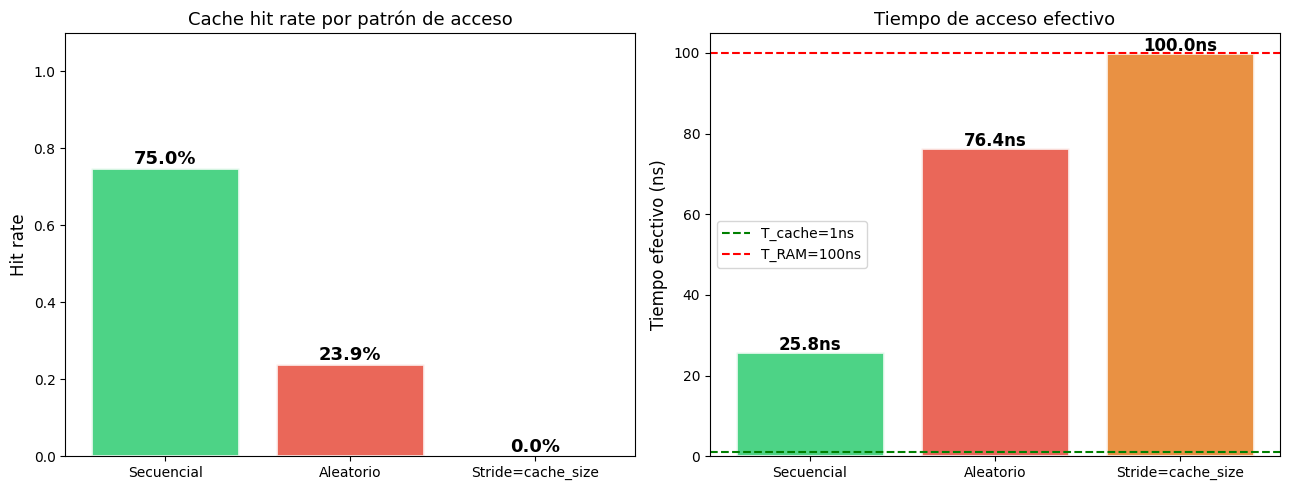

In [22]:
import numpy as np
import matplotlib.pyplot as plt

# Simulación del efecto de la caché en el tiempo de acceso
# Modelo: cache de acceso directo (direct-mapped)

class DirectMappedCache:
    def __init__(self, cache_size, block_size=4):
        self.size = cache_size           # número de bloques
        self.block_size = block_size     # palabras por bloque
        self.tags = [-1] * cache_size    # tag almacenado en cada línea
        self.hits = 0
        self.misses = 0

    def access(self, address):
        block_num = address // self.block_size
        index = block_num % self.size    # línea de caché
        tag = block_num // self.size
        if self.tags[index] == tag:
            self.hits += 1
            return True
        else:
            self.misses += 1
            self.tags[index] = tag
            return False

    def hit_rate(self):
        total = self.hits + self.misses
        return self.hits / total if total > 0 else 0

# Comparar acceso secuencial vs aleatorio
mem_size = 1024
cache_size = 64

# Patrón 1: acceso secuencial (alta localidad)
cache1 = DirectMappedCache(cache_size)
for i in range(mem_size * 3):  # 3 pasadas
    cache1.access(i % mem_size)

# Patrón 2: acceso aleatorio (baja localidad)
rng = np.random.default_rng(42)
cache2 = DirectMappedCache(cache_size)
for addr in rng.integers(0, mem_size, mem_size * 3):
    cache2.access(int(addr))

# Patrón 3: acceso con stride (thrashing)
cache3 = DirectMappedCache(cache_size)
for i in range(mem_size * 3):
    cache3.access((i * cache_size) % mem_size)

patterns = ['Secuencial', 'Aleatorio', 'Stride=cache_size']
hit_rates = [cache1.hit_rate(), cache2.hit_rate(), cache3.hit_rate()]

T_cache, T_ram = 1, 100  # ns
t_eff = [h * T_cache + (1-h) * T_ram for h in hit_rates]

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

colors = ['#2ECC71', '#E74C3C', '#E67E22']
bars = axes[0].bar(patterns, hit_rates, color=colors, alpha=0.85, edgecolor='white', linewidth=2)
for bar, h in zip(bars, hit_rates):
    axes[0].text(bar.get_x()+bar.get_width()/2, h+0.01, f'{h:.1%}',
                ha='center', fontsize=13, fontweight='bold')
axes[0].set_ylabel('Hit rate', fontsize=12)
axes[0].set_title('Cache hit rate por patrón de acceso', fontsize=13)
axes[0].set_ylim(0, 1.1)

bars2 = axes[1].bar(patterns, t_eff, color=colors, alpha=0.85, edgecolor='white', linewidth=2)
for bar, t in zip(bars2, t_eff):
    axes[1].text(bar.get_x()+bar.get_width()/2, t+0.5, f'{t:.1f}ns',
                ha='center', fontsize=12, fontweight='bold')
axes[1].axhline(y=T_cache, color='green', linestyle='--', label=f'T_cache={T_cache}ns')
axes[1].axhline(y=T_ram,   color='red',   linestyle='--', label=f'T_RAM={T_ram}ns')
axes[1].set_ylabel('Tiempo efectivo (ns)', fontsize=12)
axes[1].set_title('Tiempo de acceso efectivo', fontsize=13)
axes[1].legend(fontsize=10)

plt.tight_layout()
plt.show()

### 2.4 Procesos, Hilos, Concurrencia y Paralelismo

#### Proceso

Un **proceso** es un programa en ejecución. Tiene su propio:
- Espacio de direcciones virtuales
- Stack, heap, segmento de código y datos
- Tabla de archivos abiertos
- Estado del procesador (registros, PC)

#### Hilo (*Thread*)

Un **hilo** es la unidad mínima de ejecución *dentro* de un proceso.
Todos los hilos del mismo proceso comparten: código, heap y datos globales,
pero cada uno tiene su **propio stack** y registros.

```
Proceso P
├── Código compartido
├── Heap compartido
├── Hilo 1: [stack, PC, registros]
├── Hilo 2: [stack, PC, registros]
└── Hilo 3: [stack, PC, registros]
```

#### Concurrencia vs Paralelismo

| Concepto | Definición | Ejemplo |
|----------|------------|---------|
| **Concurrencia** | Múltiples tareas *progresan* en intervalos solapados | 1 CPU con context switching |
| **Paralelismo** | Múltiples tareas *ejecutan* simultáneamente | 4 CPUs reales |

> *La concurrencia es un problema de **estructura**;
> el paralelismo es un problema de **ejecución**.* — Rob Pike

#### Condición de carrera (*Race condition*)

Ocurre cuando el resultado depende del orden de ejecución de hilos.

```python
# Incorrecto: dos hilos leyendo/escribiendo 'counter' sin sincronización
counter = 0
def increment(): counter += 1   # NO ATÓMICA: read, add, write
```

#### Mecanismos de sincronización

| Mecanismo | Uso |
|-----------|-----|
| **Mutex** (lock) | Exclusión mutua: solo un hilo a la vez |
| **Semáforo** | Controlar acceso a $n$ recursos |
| **Monitor** | Mutex + variable de condición |
| **Barrera** | Esperar a que todos lleguen a un punto |

In [23]:
import threading
import time

# Demostración de race condition y su solución con lock

def test_counter(use_lock=False, n_threads=10, increments=10000):
    counter = [0]  # mutable via lista
    lock = threading.Lock()

    def worker():
        for _ in range(increments):
            if use_lock:
                with lock:
                    counter[0] += 1
            else:
                counter[0] += 1  # race condition!

    threads = [threading.Thread(target=worker) for _ in range(n_threads)]
    start = time.perf_counter()
    for t in threads: t.start()
    for t in threads: t.join()
    elapsed = time.perf_counter() - start
    expected = n_threads * increments
    return counter[0], expected, elapsed

# Sin lock
val_unsafe, expected, t1 = test_counter(use_lock=False)
# Con lock
val_safe, _,  t2 = test_counter(use_lock=True)

print(f'Sin lock:  valor={val_unsafe:>7}, esperado={expected}, error={expected-val_unsafe:>6}, t={t1:.3f}s')
print(f'Con lock:  valor={val_safe:>7},  esperado={expected}, error={expected-val_safe:>6},  t={t2:.3f}s')
print(f'\nOverhead del lock: {(t2-t1)/t1*100:.1f}% más lento')
print(f'Precio de correctitud: {t2/t1:.2f}x el tiempo')

Sin lock:  valor= 100000, esperado=100000, error=     0, t=0.012s
Con lock:  valor= 100000,  esperado=100000, error=     0,  t=0.040s

Overhead del lock: 243.9% más lento
Precio de correctitud: 3.44x el tiempo


---
## 3. Lenguajes de Programación

### 3.1 Clasificación de Lenguajes

#### Por nivel de abstracción

| Nivel | Ejemplos | Características |
|-------|----------|-----------------|
| **Máquina** | Binario nativo | 0s y 1s, específico de arquitectura |
| **Ensamblador** | x86 ASM, MIPS | Mnemonics, 1:1 con instrucciones máquina |
| **Bajo nivel** | C, Rust | Control de memoria, sin GC, compilados |
| **Alto nivel** | Python, Java, Haskell | Abstracción elevada, portabilidad |

#### Por estrategia de traducción

```
Código fuente
     │
     ├──[Compilador]──→ Código máquina  →  Ejecución directa  (C, C++, Rust, Go)
     │
     ├──[Intérprete]──→ Ejecución directa línea a línea       (Python básico, Ruby)
     │
     └──[Compilador]──→ Bytecode  ──[VM/JIT]──→ Ejecución     (Java, Python/CPython, C#)
```

| Estrategia | Velocidad | Portabilidad | Debug |
|------------|-----------|--------------|-------|
| Compilado | Muy rápida | Depende de arch | Difícil |
| Interpretado | Lenta | Alta | Fácil |
| Bytecode + JIT | Rápida | Alta (VM) | Media |

#### Por paradigma (adelanto)

Imperativo · Orientado a objetos · Funcional · Lógico · Concurrente · Multi-paradigma

### 3.2 Sistema de Tipos

#### Dimensión 1: Momento de verificación

**Tipado estático**: los tipos se verifican en **tiempo de compilación**.

```java
// Java — error en compilación
int x = "hola";  // incompatible types: String cannot be converted to int
```

**Tipado dinámico**: los tipos se verifican en **tiempo de ejecución**.

```python
# Python — error solo al ejecutar
x = 5
x = x + "hola"   # TypeError: unsupported operand type(s) for +: 'int' and 'str'
```

#### Dimensión 2: Fuerza de conversión implícita

**Tipado fuerte**: no se permiten conversiones implícitas entre tipos incompatibles.

```python
# Python es fuertemente tipado
1 + '1'  # TypeError
```

**Tipado débil**: se permiten conversiones implícitas.

```javascript
// JavaScript es débilmente tipado
1 + '1'   // '11'  (coercion implícita)
1 - '1'   // 0
[] + {}   // '[object Object]'
```

#### Cuadro de clasificación

```
             Fuerte              Débil
Estático:    Java, C#, Rust     C (casts implícitos)
Dinámico:    Python, Ruby       JavaScript, PHP
```

#### Inferencia de tipos

Lenguajes como **Haskell**, **Rust** y **OCaml** tienen tipado estático
pero **infieren** los tipos automáticamente:
```rust
let x = 42;         // inferido: i32
let v = vec![1,2,3];// inferido: Vec<i32>
```

In [24]:
# Ilustración del sistema de tipos en Python con type hints
# Python es dinámico y fuerte, pero admite anotaciones estáticas (PEP 484)

from typing import List, Dict, Optional, Union, Callable
import sys

# 1. Tipos básicos y verificación en tiempo de ejecución
def add_typed(a: int, b: int) -> int:
    if not isinstance(a, int) or not isinstance(b, int):
        raise TypeError(f'Se esperan int, se recibieron {type(a).__name__} y {type(b).__name__}')
    return a + b

# 2. Polimorfismo de tipos con Union
def stringify(val: Union[int, float, str, list]) -> str:
    if isinstance(val, list):
        return '[' + ', '.join(str(x) for x in val) + ']'
    return str(val)

# 3. Tipos genéricos
def first(lst: List) -> Optional[object]:
    return lst[0] if lst else None

# 4. Tipos funcionales (funciones como valores)
def apply_twice(f: Callable[[int], int], x: int) -> int:
    return f(f(x))

# Demostración
print('=== Sistema de tipos en Python ===')
print(f'add_typed(3, 4) = {add_typed(3, 4)}')
try:
    add_typed(3, '4')
except TypeError as e:
    print(f'TypeError: {e}')

print(f'stringify(42) = {stringify(42)}')
print(f'stringify(3.14) = {stringify(3.14)}')
print(f'stringify([1,2,3]) = {stringify([1, 2, 3])}')

double = lambda x: x * 2
print(f'apply_twice(double, 3) = {apply_twice(double, 3)}')

# 5. Comparación de representaciones en memoria
print('\n=== Tamaños en memoria ===')
for obj in [True, 1, 1.0, 'a', [], {}, (1,)]:
    print(f'  {repr(obj):<12} tipo={type(obj).__name__:<8} size={sys.getsizeof(obj):>5} bytes')

=== Sistema de tipos en Python ===
add_typed(3, 4) = 7
TypeError: Se esperan int, se recibieron int y str
stringify(42) = 42
stringify(3.14) = 3.14
stringify([1,2,3]) = [1, 2, 3]
apply_twice(double, 3) = 12

=== Tamaños en memoria ===
  True         tipo=bool     size=   28 bytes
  1            tipo=int      size=   28 bytes
  1.0          tipo=float    size=   24 bytes
  'a'          tipo=str      size=   42 bytes
  []           tipo=list     size=   56 bytes
  {}           tipo=dict     size=   64 bytes
  (1,)         tipo=tuple    size=   48 bytes


### 3.3 Ejemplo multilenguaje: Quicksort

El mismo algoritmo expresado en cuatro lenguajes muestra las diferencias filosóficas:

#### C (imperativo, bajo nivel)
```c
void swap(int* a, int* b) { int t = *a; *a = *b; *b = t; }

int partition(int arr[], int low, int high) {
    int pivot = arr[high], i = low - 1;
    for (int j = low; j < high; j++)
        if (arr[j] <= pivot) { i++; swap(&arr[i], &arr[j]); }
    swap(&arr[i+1], &arr[high]);
    return i + 1;
}

void quicksort(int arr[], int low, int high) {
    if (low < high) {
        int pi = partition(arr, low, high);
        quicksort(arr, low, pi-1);
        quicksort(arr, pi+1, high);
    }
}
```

#### Java (OOP)
```java
public class Quicksort {
    public static <T extends Comparable<T>> void sort(T[] arr, int lo, int hi) {
        if (lo < hi) {
            int p = partition(arr, lo, hi);
            sort(arr, lo, p - 1);
            sort(arr, p + 1, hi);
        }
    }
}
```

#### Haskell (funcional puro)
```haskell
quicksort :: Ord a => [a] -> [a]
quicksort []     = []
quicksort (x:xs) = quicksort smaller ++ [x] ++ quicksort larger
  where smaller = filter (<= x) xs
        larger  = filter (>  x) xs
```

#### Python (multi-paradigma)
```python
# Funcional
qs = lambda xs: ([] if not xs else
    qs([x for x in xs[1:] if x <= xs[0]]) + [xs[0]] +
    qs([x for x in xs[1:] if x >  xs[0]]))
```

---
## 4. Paradigmas de Programación

### 4.1 Paradigma Imperativo

El paradigma **imperativo** describe la computación como una secuencia de
instrucciones que **modifican el estado** del programa.

#### Características

- **Estado mutable**: variables que cambian de valor
- **Flujo de control explícito**: `if`, `for`, `while`, `goto`
- **Efectos secundarios**: las funciones pueden modificar estado externo
- **Modelo de Von Neumann**: refleja directamente la arquitectura del hardware

#### Subestructuras

| Subparadigma | Descripción | Ejemplos |
|--------------|-------------|----------|
| **Procedimental** | Organización en procedimientos/funciones | C, Pascal, Fortran |
| **Estructurado** | Elimina `goto`; solo seq/sel/iter | C, Java (estructuras básicas) |
| **OOP** | Estado encapsulado en objetos | Java, C++, Python |

In [25]:
# Paradigma imperativo: simulación de un banco
# Estado explícito, mutación directa

# Estado global
accounts = {}
transaction_log = []

def create_account(owner: str, balance: float = 0.0) -> str:
    acc_id = f'ACC{len(accounts)+1:04d}'
    accounts[acc_id] = {'owner': owner, 'balance': balance}
    transaction_log.append(f'OPEN {acc_id} owner={owner} balance={balance}')
    return acc_id

def deposit(acc_id: str, amount: float) -> None:
    if acc_id not in accounts:
        raise ValueError(f'Cuenta {acc_id} no existe')
    accounts[acc_id]['balance'] += amount   # mutación directa
    transaction_log.append(f'DEPOSIT {acc_id} +{amount}')

def withdraw(acc_id: str, amount: float) -> bool:
    if accounts[acc_id]['balance'] >= amount:
        accounts[acc_id]['balance'] -= amount
        transaction_log.append(f'WITHDRAW {acc_id} -{amount}')
        return True
    transaction_log.append(f'FAILED_WITHDRAW {acc_id} -{amount} (insuficiente)')
    return False

def transfer(src: str, dst: str, amount: float) -> bool:
    if withdraw(src, amount):
        deposit(dst, amount)
        return True
    return False

# Ejecución imperativa: secuencia de instrucciones con efectos
a1 = create_account('Alice', 1000)
a2 = create_account('Bob', 500)
deposit(a1, 200)
withdraw(a2, 100)
transfer(a1, a2, 300)
withdraw(a2, 1000)  # fallará

print('=== Estado final ===')
for acc_id, info in accounts.items():
    print(f'  {acc_id}: {info["owner"]:>6} — ${info["balance"]:,.2f}')

print('\n=== Log de transacciones ===')
for entry in transaction_log:
    print(f'  {entry}')

=== Estado final ===
  ACC0001:  Alice — $900.00
  ACC0002:    Bob — $700.00

=== Log de transacciones ===
  OPEN ACC0001 owner=Alice balance=1000
  OPEN ACC0002 owner=Bob balance=500
  DEPOSIT ACC0001 +200
  WITHDRAW ACC0002 -100
  WITHDRAW ACC0001 -300
  DEPOSIT ACC0002 +300
  FAILED_WITHDRAW ACC0002 -1000 (insuficiente)


### 4.2 Programación Orientada a Objetos (OOP)

La OOP organiza el código en **objetos** que encapsulan estado y comportamiento.

#### Cuatro pilares

##### 1. Encapsulamiento
Ocultar la representación interna y exponer solo una interfaz.

```python
class BankAccount:
    def __init__(self, balance):
        self.__balance = balance    # privado: acceso controlado

    def deposit(self, amount):      # interfaz pública
        if amount > 0:
            self.__balance += amount
```

##### 2. Herencia
Una clase hija **hereda** estado y comportamiento de la clase padre,
permitiendo especialización sin repetición (*DRY*).

$$\text{SavingsAccount} \xrightarrow{\text{es-un}} \text{BankAccount}$$

##### 3. Polimorfismo
La misma operación se comporta diferente según el tipo concreto del objeto.
Tipos principales:
- **Subtipo** (runtime): método sobrescrito en subclase
- **Paramétrico** (generics): código que funciona con cualquier tipo
- **Ad-hoc** (overloading): mismo nombre, distinta firma

##### 4. Abstracción
Modelar la complejidad mediante interfaces y clases abstractas,
separando **qué hace** de **cómo lo hace**.

In [26]:
from abc import ABC, abstractmethod
from typing import List
import math

# ABSTRACCIÓN + HERENCIA + POLIMORFISMO

class Shape(ABC):  # Clase abstracta: define interfaz
    def __init__(self, color: str = 'negro'):
        self.color = color  # estado encapsulado

    @abstractmethod
    def area(self) -> float: ...

    @abstractmethod
    def perimeter(self) -> float: ...

    def describe(self) -> str:  # método concreto compartido
        return (f'{type(self).__name__}(color={self.color}, '
                f'area={self.area():.4f}, perimeter={self.perimeter():.4f})')

    def __repr__(self):
        return self.describe()

class Circle(Shape):
    def __init__(self, radius: float, **kw):
        super().__init__(**kw)
        self.__radius = radius   # ENCAPSULAMIENTO: atributo privado

    @property
    def radius(self): return self.__radius

    @radius.setter
    def radius(self, r):
        if r <= 0: raise ValueError('Radio debe ser positivo')
        self.__radius = r

    def area(self) -> float: return math.pi * self.__radius ** 2
    def perimeter(self) -> float: return 2 * math.pi * self.__radius

class Rectangle(Shape):
    def __init__(self, w: float, h: float, **kw):
        super().__init__(**kw)
        self.w, self.h = w, h

    def area(self) -> float: return self.w * self.h
    def perimeter(self) -> float: return 2 * (self.w + self.h)

class Triangle(Shape):
    def __init__(self, a: float, b: float, c: float, **kw):
        super().__init__(**kw)
        if a+b <= c or a+c <= b or b+c <= a:
            raise ValueError('Lados inválidos para un triángulo')
        self.a, self.b, self.c = a, b, c

    def area(self) -> float:
        s = (self.a + self.b + self.c) / 2  # Heron
        return math.sqrt(s*(s-self.a)*(s-self.b)*(s-self.c))

    def perimeter(self) -> float: return self.a + self.b + self.c

# POLIMORFISMO: la misma función opera sobre distintos tipos
def total_area(shapes: List[Shape]) -> float:
    return sum(s.area() for s in shapes)  # dispatch dinámico

shapes: List[Shape] = [
    Circle(5, color='rojo'),
    Rectangle(4, 6, color='azul'),
    Triangle(3, 4, 5, color='verde'),
    Circle(2),
]

print('=== Polimorfismo en acción ===')
for s in shapes:
    print(f'  {s}')

print(f'\nÁrea total: {total_area(shapes):.4f}')

# HERENCIA múltiple
class Square(Rectangle):
    def __init__(self, side: float, **kw):
        super().__init__(side, side, **kw)

sq = Square(4)
print(f'\nSquare es-un Rectangle: {isinstance(sq, Rectangle)}')
print(f'Square es-un Shape:     {isinstance(sq, Shape)}')
print(f'MRO: {[c.__name__ for c in Square.__mro__]}')

=== Polimorfismo en acción ===
  Circle(color=rojo, area=78.5398, perimeter=31.4159)
  Rectangle(color=azul, area=24.0000, perimeter=20.0000)
  Triangle(color=verde, area=6.0000, perimeter=12.0000)
  Circle(color=negro, area=12.5664, perimeter=12.5664)

Área total: 121.1062

Square es-un Rectangle: True
Square es-un Shape:     True
MRO: ['Square', 'Rectangle', 'Shape', 'ABC', 'object']


### 4.3 Programación Funcional

El paradigma funcional modela la computación como la evaluación de
**funciones matemáticas puras**, evitando el estado mutable y los efectos secundarios.

#### Conceptos fundamentales

##### Función pura
Una función $f$ es **pura** si:
1. Para los mismos argumentos siempre retorna el mismo valor
2. No tiene efectos secundarios observables

$$f(x) = x^2 + 1 \quad \text{(pura)}$$

##### Inmutabilidad
Los valores, una vez creados, no se modifican. Las "actualizaciones" crean
nuevas estructuras de datos.

##### Funciones de orden superior
Funciones que reciben o retornan funciones:

| Función | Tipo | Descripción |
|---------|------|-------------|
| `map(f, xs)` | $(a \to b) \to [a] \to [b]$ | Aplica $f$ a cada elemento |
| `filter(p, xs)` | $(a \to \text{bool}) \to [a] \to [a]$ | Selecciona elementos donde $p$ es True |
| `reduce(f, xs)` | $(b \to a \to b) \to [a] \to b$ | Combina elementos con $f$ |

##### Clausuras (*closures*)
Una función que **captura variables de su entorno léxico**.

##### Currying y aplicación parcial
Transformar $f: A \times B \to C$ en $f': A \to (B \to C)$.

##### Recursión de cola (*tail recursion*)
Cuando la llamada recursiva es la **última operación**, puede optimizarse
para no acumular frames de pila. Python no optimiza TCO por diseño
(Guido van Rossum, 2009).

In [27]:
from functools import reduce, partial
from typing import Callable, TypeVar, List, Iterable, Any
import operator

A = TypeVar('A')
B = TypeVar('B')

# 1. FUNCIONES PURAS
def pure_add(a: int, b: int) -> int:
    return a + b  # sin efectos secundarios, determinista

# 2. FUNCIONES DE ORDEN SUPERIOR implementadas desde cero
def my_map(f: Callable, xs: Iterable) -> list:
    return [f(x) for x in xs]

def my_filter(pred: Callable, xs: Iterable) -> list:
    return [x for x in xs if pred(x)]

def my_reduce(f: Callable, xs: list, initial=None):
    acc = initial if initial is not None else xs[0]
    for x in (xs if initial is not None else xs[1:]):
        acc = f(acc, x)
    return acc

# 3. COMPOSICIÓN DE FUNCIONES
def compose(*fns):
    # (f ∘ g)(x) = f(g(x))
    def composed(x):
        result = x
        for f in reversed(fns):
            result = f(result)
        return result
    return composed

# 4. CURRYING manual
def curry2(f):
    return lambda a: lambda b: f(a, b)

add = curry2(operator.add)
add5 = add(5)  # aplicación parcial: función que suma 5

# 5. CLAUSURA
def make_multiplier(factor: int) -> Callable[[int], int]:
    # 'factor' es capturado del entorno léxico
    return lambda x: x * factor

double = make_multiplier(2)
triple = make_multiplier(3)

# 6. PIPELINE funcional — mismo resultado que el bucle imperativo
data = list(range(1, 21))

# Imperativo:
result_imp = []
for x in data:
    if x % 2 == 0:
        result_imp.append(x ** 2)
total_imp = sum(result_imp)

# Funcional:
is_even  = lambda x: x % 2 == 0
square   = lambda x: x * x
pipeline = compose(
    lambda xs: my_reduce(operator.add, xs, 0),  # sum
    lambda xs: my_map(square, xs),              # map^2
    lambda xs: my_filter(is_even, xs),          # filter even
)
total_func = pipeline(data)

print('=== Funciones de orden superior ===')
print(f'map(x²,  [1..5]) = {my_map(square, range(1,6))}')
print(f'filter(par, [1..10]) = {my_filter(is_even, range(1,11))}')
print(f'reduce(+, [1..5]) = {my_reduce(operator.add, list(range(1,6)))}')

print('\n=== Clausuras ===')
print(f'double(7) = {double(7)},  triple(7) = {triple(7)}')

print('\n=== Currying ===')
print(f'add5(10) = {add5(10)}')

print('\n=== Pipeline funcional vs imperativo ===')
print(f'Σ(x² para x par en [1..20]) = {total_func}')
print(f'Mismo con imperativo        = {total_imp}')
print(f'Iguales: {total_func == total_imp}')

=== Funciones de orden superior ===
map(x²,  [1..5]) = [1, 4, 9, 16, 25]
filter(par, [1..10]) = [2, 4, 6, 8, 10]
reduce(+, [1..5]) = 15

=== Clausuras ===
double(7) = 14,  triple(7) = 21

=== Currying ===
add5(10) = 15

=== Pipeline funcional vs imperativo ===
Σ(x² para x par en [1..20]) = 1540
Mismo con imperativo        = 1540
Iguales: True


### 4.4 Comparación de Paradigmas

#### Problema: calcular la suma de cuadrados de números impares en [1, n]

```
sum( x² para x en [1..n] si x es impar )
```

| Paradigma | Estilo | Característica clave |
|-----------|--------|---------------------|
| **Imperativo** | Bucle `for`, variable acumuladora | Descripción del *cómo* |
| **Funcional** | `map + filter + reduce` | Descripción del *qué* |
| **OOP** | Clase `NumberStream` | Encapsulación del estado y operaciones |
| **Declarativo** | List comprehension / SQL-like | Especificación del resultado |

In [28]:
import operator
from functools import reduce

n = 20

# --- Imperativo ---
def sum_odd_sq_imperative(n: int) -> int:
    total = 0
    for x in range(1, n+1):
        if x % 2 != 0:
            total += x * x
    return total

# --- Funcional ---
def sum_odd_sq_functional(n: int) -> int:
    return reduce(
        operator.add,
        map(lambda x: x*x,
            filter(lambda x: x % 2 != 0,
                   range(1, n+1))),
        0
    )

# --- Declarativo (comprensión de lista) ---
def sum_odd_sq_declarative(n: int) -> int:
    return sum(x*x for x in range(1, n+1) if x % 2 != 0)

# --- OOP ---
class NumberStream:
    def __init__(self, iterable):
        self._data = list(iterable)

    def filter(self, pred):
        return NumberStream(x for x in self._data if pred(x))

    def map(self, f):
        return NumberStream(f(x) for x in self._data)

    def sum(self): return sum(self._data)

def sum_odd_sq_oop(n: int) -> int:
    return (NumberStream(range(1, n+1))
            .filter(lambda x: x % 2 != 0)
            .map(lambda x: x * x)
            .sum())

results = {
    'Imperativo':   sum_odd_sq_imperative(n),
    'Funcional':    sum_odd_sq_functional(n),
    'Declarativo':  sum_odd_sq_declarative(n),
    'OOP':          sum_odd_sq_oop(n),
}

print(f'Σ(x² para x impar en [1..{n}])')
print()
for paradigma, val in results.items():
    print(f'  {paradigma:<16}: {val}')

assert len(set(results.values())) == 1, 'Los resultados deben ser iguales'
print('\n✓ Todos los paradigmas producen el mismo resultado')

Σ(x² para x impar en [1..20])

  Imperativo      : 1330
  Funcional       : 1330
  Declarativo     : 1330
  OOP             : 1330

✓ Todos los paradigmas producen el mismo resultado


---
## 5. Estructuras de Datos

### 5.1 Arrays (Arreglos)

#### Definición formal

Un **array** es una secuencia contigua de $n$ elementos del mismo tipo almacenados
en memoria. Si la dirección base es $B$ y cada elemento ocupa $s$ bytes:

$$\text{dirección}(A[i]) = B + i \cdot s$$

Esta fórmula hace que el acceso sea $O(1)$ — constante independiente de $n$.

#### Complejidades

| Operación | Tiempo | Notas |
|-----------|--------|-------|
| Acceso `A[i]` | $O(1)$ | Aritmética de puntero |
| Búsqueda | $O(n)$ | Lineal; $O(\log n)$ si ordenado |
| Inserción al final | $O(1)^*$ | Amortizado si dinámico |
| Inserción en posición $i$ | $O(n)$ | Hay que desplazar $n-i$ elementos |
| Eliminación | $O(n)$ | Igual: desplazar elementos |

#### Arrays dinámicos

Los arrays dinámicos (Python `list`, Java `ArrayList`, C++ `vector`) duplican
su capacidad cuando se llenan:

$$\text{Costo amortizado de append} = O(1)$$

In [29]:
import ctypes
import sys

# Array de bajo nivel usando ctypes (similar a C)
class RawArray:
    def __init__(self, capacity: int = 4):
        self._n = 0
        self._cap = capacity
        self._arr = self._make_array(capacity)

    def _make_array(self, cap):
        return (cap * ctypes.py_object)()

    def __len__(self): return self._n

    def __getitem__(self, i):
        if not 0 <= i < self._n:
            raise IndexError('Índice fuera de rango')
        return self._arr[i]

    def append(self, val):
        if self._n == self._cap:
            self._resize(2 * self._cap)  # duplicar capacidad
        self._arr[self._n] = val
        self._n += 1

    def _resize(self, new_cap):
        new_arr = self._make_array(new_cap)
        for i in range(self._n):
            new_arr[i] = self._arr[i]
        self._arr = new_arr
        self._cap = new_cap

    def insert(self, i: int, val):
        if self._n == self._cap:
            self._resize(2 * self._cap)
        # Desplazar elementos a la derecha: O(n)
        for j in range(self._n, i, -1):
            self._arr[j] = self._arr[j-1]
        self._arr[i] = val
        self._n += 1

    def __repr__(self):
        return '[' + ', '.join(str(self._arr[i]) for i in range(self._n)) + ']'

# Demo y verificación del crecimiento de capacidad
a = RawArray()
print('Crecimiento dinámico (n, cap, size en bytes):')
print(f'  {"n":>4} | {"cap":>4}')
prev_cap = a._cap
for i in range(17):
    a.append(i * 10)
    if a._cap != prev_cap or i < 5:
        print(f'  {i+1:>4} | {a._cap:>4}  <- resize!' if a._cap != prev_cap else f'  {i+1:>4} | {a._cap:>4}')
        prev_cap = a._cap

a.insert(2, 999)
print(f'\nDespués de insert(2, 999): {a}')

Crecimiento dinámico (n, cap, size en bytes):
     n |  cap
     1 |    4
     2 |    4
     3 |    4
     4 |    4
     5 |    8  <- resize!
     9 |   16  <- resize!
    17 |   32  <- resize!

Después de insert(2, 999): [0, 10, 999, 20, 30, 40, 50, 60, 70, 80, 90, 100, 110, 120, 130, 140, 150, 160]


### 5.2 Listas Enlazadas

#### Definición formal

Una **lista enlazada** es una colección de nodos donde cada nodo contiene un
**dato** y un **puntero** al siguiente nodo:

$$\text{Node} = (\text{data}: T,\; \text{next}: \text{Node}^*)$$

```
head
 │
 ▼
[10│─]──→[20│─]──→[30│─]──→[40│╳]
```

#### Complejidades

| Operación | Enlazada simple | Array |
|-----------|-----------------|-------|
| Acceso `[i]` | $O(n)$ | $O(1)$ |
| Inserción al inicio | $O(1)$ | $O(n)$ |
| Inserción al final | $O(n)$ / $O(1)$ con tail | $O(1)^*$ |
| Eliminación al inicio | $O(1)$ | $O(n)$ |
| Búsqueda | $O(n)$ | $O(n)$ |
| Espacio | $O(n)$ + overhead punteros | $O(n)$ |

#### Variantes
- **Simplemente enlazada**: un puntero `next`
- **Doblemente enlazada**: punteros `prev` y `next`
- **Circular**: el último nodo apunta al primero

In [30]:
from typing import Optional, TypeVar

T = TypeVar('T')

class Node:
    __slots__ = ('data', 'next')
    def __init__(self, data, nxt=None):
        self.data = data
        self.next = nxt

class LinkedList:
    def __init__(self):
        self.head: Optional[Node] = None
        self.tail: Optional[Node] = None
        self._size = 0

    def prepend(self, val):       # O(1)
        node = Node(val, self.head)
        self.head = node
        if self.tail is None:
            self.tail = node
        self._size += 1

    def append(self, val):        # O(1) con tail pointer
        node = Node(val)
        if self.tail:
            self.tail.next = node
        else:
            self.head = node
        self.tail = node
        self._size += 1

    def delete_first(self, val) -> bool:  # O(n)
        prev, curr = None, self.head
        while curr:
            if curr.data == val:
                if prev:
                    prev.next = curr.next
                else:
                    self.head = curr.next
                if curr.next is None:
                    self.tail = prev
                self._size -= 1
                return True
            prev, curr = curr, curr.next
        return False

    def reverse(self):            # O(n), O(1) espacio extra
        prev, curr = None, self.head
        self.tail = self.head
        while curr:
            nxt = curr.next
            curr.next = prev
            prev = curr
            curr = nxt
        self.head = prev

    def __len__(self): return self._size

    def __iter__(self):
        curr = self.head
        while curr:
            yield curr.data
            curr = curr.next

    def __repr__(self):
        return ' → '.join(str(x) for x in self) + ' → None'

ll = LinkedList()
for v in [10, 20, 30, 40, 50]:
    ll.append(v)
ll.prepend(0)

print(f'Lista:        {ll}')
print(f'Longitud:     {len(ll)}')
ll.delete_first(30)
print(f'Sin 30:       {ll}')
ll.reverse()
print(f'Invertida:    {ll}')

Lista:        0 → 10 → 20 → 30 → 40 → 50 → None
Longitud:     6
Sin 30:       0 → 10 → 20 → 40 → 50 → None
Invertida:    50 → 40 → 20 → 10 → 0 → None


### 5.3 Pilas y Colas

#### Pila (Stack) — LIFO

Una **pila** permite insertar y extraer solo por un extremo (*top*).

$$\text{push}(x): \text{top} \leftarrow x \qquad \text{pop}(): \text{retorna top y lo elimina}$$

**Complejidad**: push $O(1)$, pop $O(1)$, peek $O(1)$.

**Aplicaciones**: evaluación de expresiones, DFS, backtracking, call stack.

#### Cola (Queue) — FIFO

Una **cola** inserta por un extremo (*rear*) y extrae por el otro (*front*).

$$\text{enqueue}(x): \text{rear} \leftarrow x \qquad \text{dequeue}(): \text{retorna front y lo elimina}$$

**Complejidad**: enqueue $O(1)$, dequeue $O(1)$.

**Aplicaciones**: BFS, scheduling, buffers.

#### Cola de doble extremo (Deque)

Permite inserción/extracción en ambos extremos en $O(1)$.

In [31]:
from collections import deque
from typing import Generic, TypeVar

T = TypeVar('T')

# --- Stack ---
class Stack:
    def __init__(self):
        self._data = []

    def push(self, val): self._data.append(val)
    def pop(self):
        if not self._data: raise IndexError('Stack vacío')
        return self._data.pop()
    def peek(self):
        if not self._data: raise IndexError('Stack vacío')
        return self._data[-1]
    def is_empty(self): return len(self._data) == 0
    def __len__(self): return len(self._data)
    def __repr__(self): return f'Stack({self._data})'

# --- Queue con lista circular interna ---
class Queue:
    def __init__(self, capacity=16):
        self._arr = [None] * capacity
        self._front = 0
        self._size = 0
        self._cap = capacity

    def enqueue(self, val):
        if self._size == self._cap:
            self._resize()
        rear = (self._front + self._size) % self._cap
        self._arr[rear] = val
        self._size += 1

    def dequeue(self):
        if self._size == 0: raise IndexError('Cola vacía')
        val = self._arr[self._front]
        self._front = (self._front + 1) % self._cap
        self._size -= 1
        return val

    def _resize(self):
        new_cap = 2 * self._cap
        new_arr = [None] * new_cap
        for i in range(self._size):
            new_arr[i] = self._arr[(self._front + i) % self._cap]
        self._arr = new_arr
        self._front = 0
        self._cap = new_cap

    def is_empty(self): return self._size == 0
    def __len__(self): return self._size

# Aplicación: verificador de paréntesis balanceados
def is_balanced(expr: str) -> bool:
    stack = Stack()
    pairs = {')': '(', ']': '[', '}': '{'}
    for ch in expr:
        if ch in '([{': stack.push(ch)
        elif ch in ')]}':
            if stack.is_empty() or stack.pop() != pairs[ch]:
                return False
    return stack.is_empty()

# Aplicación: evaluador de expresiones postfijas (RPN)
def eval_rpn(tokens: list) -> float:
    stack = Stack()
    ops = {'+': lambda a,b: a+b, '-': lambda a,b: a-b,
           '*': lambda a,b: a*b, '/': lambda a,b: a/b}
    for tok in tokens:
        if tok in ops:
            b, a = stack.pop(), stack.pop()
            stack.push(ops[tok](a, b))
        else:
            stack.push(float(tok))
    return stack.pop()

print('=== Stack: paréntesis balanceados ===')
for expr in ['(a+b)*[c-{d/e}]', '((())', '{}[]()']:
    print(f'  {expr!r:25} -> {"OK" if is_balanced(expr) else "ERROR"}')

print('\n=== Stack: evaluador RPN ===')
# 3 4 + 2 * = (3+4)*2 = 14
tokens = ['3', '4', '+', '2', '*']
print(f'  {" ".join(tokens)} = {eval_rpn(tokens)}')
# 5 1 2 + 4 * + 3 - = 5+(1+2)*4-3 = 14
tokens2 = ['5','1','2','+','4','*','+','3','-']
print(f'  {" ".join(tokens2)} = {eval_rpn(tokens2)}')

print('\n=== Queue circular ===')
q = Queue(4)
for v in [10,20,30,40]:
    q.enqueue(v)
print(f'  Dequeue: {q.dequeue()}, {q.dequeue()}')
q.enqueue(50); q.enqueue(60)
while not q.is_empty():
    print(f'  Dequeue: {q.dequeue()}')

=== Stack: paréntesis balanceados ===
  '(a+b)*[c-{d/e}]'         -> OK
  '((())'                   -> ERROR
  '{}[]()'                  -> OK

=== Stack: evaluador RPN ===
  3 4 + 2 * = 14.0
  5 1 2 + 4 * + 3 - = 14.0

=== Queue circular ===
  Dequeue: 10, 20
  Dequeue: 30
  Dequeue: 40
  Dequeue: 50
  Dequeue: 60


### 5.4 Tablas Hash

#### Definición formal

Una **tabla hash** implementa el TAD *diccionario* mapeando claves a valores
mediante una función $h: K \to \{0, 1, \ldots, m-1\}$.

#### Función hash ideal

Una buena función hash debe:
1. **Determinista**: misma clave → misma celda
2. **Uniforme**: distribuir claves uniformemente
3. **Rápida**: $O(1)$ para calcular

Función hash clásica para enteros:
$$h(k) = k \bmod m \quad \text{donde } m \text{ es primo}$$

#### Colisiones

Cuando $h(k_1) = h(k_2)$ con $k_1 \neq k_2$. Estrategias:

| Estrategia | Descripción |
|------------|-------------|
| **Encadenamiento** | Cada celda tiene una lista enlazada |
| **Sondeo lineal** | Buscar la siguiente celda libre: $h(k, i) = (h(k) + i) \bmod m$ |
| **Sondeo cuadrático** | $h(k, i) = (h(k) + c_1 i + c_2 i^2) \bmod m$ |
| **Doble hashing** | $h(k, i) = (h_1(k) + i \cdot h_2(k)) \bmod m$ |

#### Factor de carga

$$\alpha = \frac{n}{m} \qquad (n = \text{claves}, m = \text{celdas})$$

Con encadenamiento, el tiempo esperado de búsqueda es $\Theta(1 + \alpha)$.
Se suele mantener $\alpha < 0.75$.

In [32]:
from typing import Optional, List, Tuple, Any

class HashMap:
    # Tabla hash con encadenamiento (separate chaining)
    _PRIME = 97  # tamaño inicial primo

    def __init__(self, capacity: int = None):
        self._m = capacity or self._PRIME
        self._buckets: List[List[Tuple]] = [[] for _ in range(self._m)]
        self._n = 0

    def _hash(self, key) -> int:
        return hash(key) % self._m

    def put(self, key, value):
        idx = self._hash(key)
        bucket = self._buckets[idx]
        for i, (k, v) in enumerate(bucket):
            if k == key:
                bucket[i] = (key, value)  # actualizar
                return
        bucket.append((key, value))
        self._n += 1
        if self.load_factor() > 0.75:
            self._rehash()

    def get(self, key, default=None):
        idx = self._hash(key)
        for k, v in self._buckets[idx]:
            if k == key: return v
        return default

    def delete(self, key) -> bool:
        idx = self._hash(key)
        bucket = self._buckets[idx]
        for i, (k, v) in enumerate(bucket):
            if k == key:
                bucket.pop(i)
                self._n -= 1
                return True
        return False

    def load_factor(self): return self._n / self._m

    def _rehash(self):
        old_buckets = self._buckets
        self._m = self._m * 2 + 1  # mantener impar
        self._buckets = [[] for _ in range(self._m)]
        self._n = 0
        for bucket in old_buckets:
            for k, v in bucket:
                self.put(k, v)

    def stats(self):
        lengths = [len(b) for b in self._buckets]
        used = sum(1 for l in lengths if l > 0)
        return {'m': self._m, 'n': self._n, 'load': self.load_factor(),
                'max_chain': max(lengths), 'used_buckets': used}

    def __contains__(self, key): return self.get(key) is not None
    def __setitem__(self, k, v): self.put(k, v)
    def __getitem__(self, k):
        v = self.get(k)
        if v is None: raise KeyError(k)
        return v

# Demo
hm = HashMap(7)  # capacidad inicial pequeña para ver rehash
words = 'to be or not to be that is the question whether tis nobler'.split()
for w in words:
    hm[w] = hm.get(w, 0) + 1

print('Frecuencia de palabras:')
for w in sorted(set(words)):
    print(f'  {w!r:12}: {hm[w]}')

print(f'\nEstadísticas: {hm.stats()}')

Frecuencia de palabras:
  'be'        : 2
  'is'        : 1
  'nobler'    : 1
  'not'       : 1
  'or'        : 1
  'question'  : 1
  'that'      : 1
  'the'       : 1
  'tis'       : 1
  'to'        : 2
  'whether'   : 1

Estadísticas: {'m': 15, 'n': 11, 'load': 0.7333333333333333, 'max_chain': 3, 'used_buckets': 8}


### 5.5 Árbol Binario de Búsqueda (BST)

#### Definición formal

Un **BST** es un árbol binario donde para cada nodo $v$ con clave $k$:

$$\forall u \in \text{subárbol izquierdo}(v) : u.\text{key} < k$$
$$\forall u \in \text{subárbol derecho}(v) : u.\text{key} > k$$

#### Complejidades

| Operación | Promedio | Peor caso |
|-----------|----------|-----------|
| Búsqueda | $O(\log n)$ | $O(n)$ (árbol degenerado) |
| Inserción | $O(\log n)$ | $O(n)$ |
| Eliminación | $O(\log n)$ | $O(n)$ |
| Mínimo/Máximo | $O(h)$ | $O(n)$ |

donde $h$ es la altura del árbol. Para un árbol balanceado, $h = O(\log n)$.

#### Árbol AVL

El **AVL** es un BST auto-balanceado donde para cada nodo:

$$|h(\text{izq}) - h(\text{der})| \leq 1$$

Garantizando $h = O(\log n)$ y todas las operaciones en $O(\log n)$.

In [33]:
from typing import Optional, List

class BSTNode:
    __slots__ = ('key', 'val', 'left', 'right')
    def __init__(self, key, val=None):
        self.key = key
        self.val = val
        self.left: Optional['BSTNode'] = None
        self.right: Optional['BSTNode'] = None

class BST:
    def __init__(self):
        self.root: Optional[BSTNode] = None
        self._size = 0

    def insert(self, key, val=None):
        self.root = self._insert(self.root, key, val)

    def _insert(self, node, key, val):
        if node is None:
            self._size += 1
            return BSTNode(key, val)
        if key < node.key:
            node.left  = self._insert(node.left, key, val)
        elif key > node.key:
            node.right = self._insert(node.right, key, val)
        else:
            node.val = val  # actualizar
        return node

    def search(self, key) -> Optional[BSTNode]:
        node = self.root
        while node:
            if key == node.key: return node
            node = node.left if key < node.key else node.right
        return None

    def delete(self, key):
        self.root = self._delete(self.root, key)

    def _delete(self, node, key):
        if node is None: return None
        if key < node.key:
            node.left  = self._delete(node.left, key)
        elif key > node.key:
            node.right = self._delete(node.right, key)
        else:  # encontrado
            self._size -= 1
            if node.left is None:  return node.right
            if node.right is None: return node.left
            # Sucesor inorder: mínimo del subárbol derecho
            succ = node.right
            while succ.left: succ = succ.left
            node.key, node.val = succ.key, succ.val
            node.right = self._delete(node.right, succ.key)
            self._size += 1  # delete decremented
        return node

    def inorder(self) -> List:
        result = []
        def _io(node):
            if node:
                _io(node.left)
                result.append(node.key)
                _io(node.right)
        _io(self.root)
        return result

    def height(self) -> int:
        def _h(node):
            if node is None: return -1
            return 1 + max(_h(node.left), _h(node.right))
        return _h(self.root)

    def visualize(self):
        # Impresión lateral del árbol
        def _print(node, level=0, prefix='Root: '):
            if node:
                print(' ' * (level*4) + prefix + str(node.key))
                if node.left or node.right:
                    if node.left:  _print(node.left,  level+1, 'L--- ')
                    else:          print(' ' * ((level+1)*4) + 'L--- None')
                    if node.right: _print(node.right, level+1, 'R--- ')
                    else:          print(' ' * ((level+1)*4) + 'R--- None')
        _print(self.root)

bst = BST()
for k in [50, 30, 70, 20, 40, 60, 80, 10, 25]:
    bst.insert(k)

print('Árbol BST:')
bst.visualize()
print(f'\nInorder (debe ser ordenado): {bst.inorder()}')
print(f'Altura: {bst.height()}  (óptima para {bst._size} nodos: {int(__import__("math").log2(bst._size))})')

bst.delete(30)
print(f'\nDespués de eliminar 30, inorder: {bst.inorder()}')

Árbol BST:
Root: 50
    L--- 30
        L--- 20
            L--- 10
            R--- 25
        R--- 40
    R--- 70
        L--- 60
        R--- 80

Inorder (debe ser ordenado): [10, 20, 25, 30, 40, 50, 60, 70, 80]
Altura: 3  (óptima para 9 nodos: 3)

Después de eliminar 30, inorder: [10, 20, 25, 40, 50, 60, 70, 80]


---
## 6. Compiladores

### 6.1 ¿Qué es un compilador?

Un **compilador** es un programa que traduce código fuente en un lenguaje fuente
a código en un lenguaje destino, preservando el significado semántico.

#### Compilador vs Intérprete

| Característica | Compilador | Intérprete |
|----------------|------------|------------|
| Traducción | Todo el programa antes de ejecutar | Línea a línea durante ejecución |
| Velocidad de ejecución | Rápida | Más lenta |
| Mensajes de error | Antes de ejecutar | Durante ejecución |
| Portabilidad | Código objeto específico | Alta (si el intérprete existe) |
| Ejemplos | GCC (C), rustc | CPython, Ruby MRI |

#### Fases del compilador

```
Código fuente
      │
      ▼
┌─────────────────┐
│  Análisis Léxico│  → tokens (flujo de lexemas)
└────────┬────────┘
         ▼
┌─────────────────────┐
│ Análisis Sintáctico │  → AST (árbol sintáctico)
└────────┬────────────┘
         ▼
┌─────────────────────┐
│ Análisis Semántico  │  → AST decorado + tabla de símbolos
└────────┬────────────┘
         ▼
┌─────────────────────────────────┐
│ Generación de código intermedio │  → IR (3-address code, LLVM IR...)
└────────┬────────────────────────┘
         ▼
┌─────────────────┐
│   Optimización  │  → IR optimizado
└────────┬────────┘
         ▼
┌──────────────────────┐
│ Generación de código │  → código máquina / bytecode
└──────────────────────┘
```

### 6.2 Análisis Léxico

El **analizador léxico** (*lexer* o *scanner*) convierte la cadena de caracteres
del fuente en una secuencia de **tokens**.

#### Token

$$\text{Token} = (\text{tipo},\; \text{lexema},\; \text{posición})$$

Ejemplos para `x = 3 + y * 2`:

| Tipo | Lexema |
|------|--------|
| `IDENT` | `x` |
| `ASSIGN` | `=` |
| `NUMBER` | `3` |
| `PLUS` | `+` |
| `IDENT` | `y` |
| `STAR` | `*` |
| `NUMBER` | `2` |

#### Implementación

Los lexers se implementan típicamente como autómatas finitos deterministas (DFA)
o mediante expresiones regulares.

$$\text{Expresión regular} \xrightarrow{\text{Thompson}} \text{NFA} \xrightarrow{\text{Subset construction}} \text{DFA} \xrightarrow{\text{Minimización}} \text{DFA mínimo}$$

In [36]:
import re
from dataclasses import dataclass
from typing import List, Iterator
from enum import Enum, auto

class TT(Enum):  # Token Types
    NUMBER   = auto()
    IDENT    = auto()
    PLUS     = auto()
    MINUS    = auto()
    STAR     = auto()
    SLASH    = auto()
    ASSIGN   = auto()
    LPAREN   = auto()
    RPAREN   = auto()
    IF       = auto()
    ELSE     = auto()
    WHILE    = auto()
    LET      = auto()
    RETURN   = auto()
    SEMICOL  = auto()
    LBRACE   = auto()
    RBRACE   = auto()
    LT       = auto()
    GT       = auto()
    EQ       = auto()
    EOF      = auto()

@dataclass
class Token:
    type: TT
    lexeme: str
    line: int
    col: int

    def __repr__(self):
        return f'Token({self.type.name}, {self.lexeme!r}, {self.line}:{self.col})'

class Lexer:
    KEYWORDS = {'if': TT.IF, 'else': TT.ELSE, 'while': TT.WHILE,
                'let': TT.LET, 'return': TT.RETURN}

    # Reglas: (patrón, tipo) — el orden importa
    TOKEN_SPEC = [
        (r'\d+(\.\d+)?',  TT.NUMBER),
        (r'[A-Za-z_]\w*',  TT.IDENT),  # identif. o keyword
        (r'==',             TT.EQ),
        (r'=',              TT.ASSIGN),
        (r'\+',            TT.PLUS),
        (r'-',              TT.MINUS),
        (r'\*',            TT.STAR),
        (r'/',              TT.SLASH),
        (r'\(',            TT.LPAREN),
        (r'\)',            TT.RPAREN),
        (r'\{',            TT.LBRACE),
        (r'\}',            TT.RBRACE),
        (r';',              TT.SEMICOL),
        (r'<',              TT.LT),
        (r'>',              TT.GT),
    ]

    def __init__(self, source: str):
        self.source = source
        self.pos = 0
        self.line = 1
        self.col = 1
        # Compilar todas las reglas en un único regex con grupos nombrados
        pattern = '|'.join(f'(?P<T{i}>{spec[0]})' for i, spec in enumerate(self.TOKEN_SPEC))
        self._master_re = re.compile(pattern)

    def tokenize(self) -> List[Token]:
        tokens = []
        for m in self._master_re.finditer(self.source):
            group_name = m.lastgroup
            if group_name is None:
                raise RuntimeError("Regex matched but no named group was captured.")

            kind_idx = int(group_name[1:]) # 'T0' -> 0, 'T1' -> 1, etc.
            tt = self.TOKEN_SPEC[kind_idx][1]
            lexeme = m.group(group_name)

            start = m.start()
            line = self.source[:start].count('\n') + 1

            last_newline = self.source[:start].rfind('\n')
            col  = start - last_newline

            if tt == TT.IDENT and lexeme in self.KEYWORDS:
                tt = self.KEYWORDS[lexeme]
            tokens.append(Token(tt, lexeme, line, col))

        eof_line = self.source.count('\n') + 1 if '\n' in self.source else 1
        tokens.append(Token(TT.EOF, '', eof_line, 0))
        return tokens

source = '''
let x = 3 + 4 * 2;
if (x > 5) {
    return x;
}
'''

lexer = Lexer(source)
tokens = lexer.tokenize()

print('Tokens generados:')
print(f'{"Tipo":<12} {"Lexema":<12} {"Pos"}')
print('-' * 38)
for tok in tokens:
    print(f'{tok.type.name:<12} {tok.lexeme!r:<12} {tok.line}:{tok.col}')

Tokens generados:
Tipo         Lexema       Pos
--------------------------------------
LET          'let'        2:1
IDENT        'x'          2:5
ASSIGN       '='          2:7
NUMBER       '3'          2:9
PLUS         '+'          2:11
NUMBER       '4'          2:13
STAR         '*'          2:15
NUMBER       '2'          2:17
SEMICOL      ';'          2:18
IF           'if'         3:1
LPAREN       '('          3:4
IDENT        'x'          3:5
GT           '>'          3:7
NUMBER       '5'          3:9
RPAREN       ')'          3:10
LBRACE       '{'          3:12
RETURN       'return'     4:5
IDENT        'x'          4:12
SEMICOL      ';'          4:13
RBRACE       '}'          5:1
EOF          ''           6:0


### 6.3 Análisis Sintáctico y AST

El **parser** verifica que la secuencia de tokens siga la gramática del lenguaje
y construye un **Árbol Sintáctico Abstracto (AST)**.

#### Gramática para expresiones aritméticas

```
expr    → term (('+' | '-') term)*
term    → factor (('*' | '/') factor)*
factor  → NUMBER | IDENT | '(' expr ')'
```

Esta gramática implementa la **precedencia de operadores** (multiplicación
antes que suma) mediante la jerarquía de no-terminales.

#### Parser de descenso recursivo

Cada no-terminal de la gramática corresponde a una función del parser.
Esta técnica implementa directamente un **LL(1)** — de izquierda a derecha,
derivación más a la izquierda, mirando 1 token adelante.

#### AST vs árbol de análisis concreto

El **árbol concreto** preserva todos los tokens. El **AST** elimina los
nodos redundantes y contiene solo la información semánticamente relevante.

In [37]:
from dataclasses import dataclass, field
from typing import Optional, List, Union

# --- Nodos del AST ---
@dataclass
class NumLiteral:
    value: float
    def __repr__(self): return f'Num({self.value})'

@dataclass
class Identifier:
    name: str
    def __repr__(self): return f'Id({self.name})'

@dataclass
class BinOp:
    op: str
    left:  'ASTNode'
    right: 'ASTNode'
    def __repr__(self): return f'BinOp({self.op}, {self.left}, {self.right})'

@dataclass
class UnaryOp:
    op: str
    operand: 'ASTNode'
    def __repr__(self): return f'Unary({self.op}, {self.operand})'

@dataclass
class Assignment:
    name: str
    value: 'ASTNode'
    def __repr__(self): return f'Assign({self.name}, {self.value})'

ASTNode = Union[NumLiteral, Identifier, BinOp, UnaryOp, Assignment]

# --- Parser de descenso recursivo ---
class Parser:
    def __init__(self, tokens: List[Token]):
        self.tokens = tokens
        self.pos = 0

    @property
    def current(self) -> Token:
        return self.tokens[self.pos]

    def consume(self, expected: TT = None) -> Token:
        tok = self.current
        if expected and tok.type != expected:
            raise SyntaxError(f'Esperaba {expected.name}, encontré {tok.type.name} ({tok.lexeme!r}) en {tok.line}:{tok.col}')
        self.pos += 1
        return tok

    def parse(self) -> ASTNode:
        node = self.expr()
        self.consume(TT.EOF)
        return node

    def expr(self) -> ASTNode:                    # expr -> term ((+|-) term)*
        node = self.term()
        while self.current.type in (TT.PLUS, TT.MINUS):
            op = self.consume().lexeme
            node = BinOp(op, node, self.term())
        return node

    def term(self) -> ASTNode:                    # term -> factor ((*|/) factor)*
        node = self.factor()
        while self.current.type in (TT.STAR, TT.SLASH):
            op = self.consume().lexeme
            node = BinOp(op, node, self.factor())
        return node

    def factor(self) -> ASTNode:                  # factor -> NUM | IDENT | -factor | (expr)
        tok = self.current
        if tok.type == TT.NUMBER:
            self.consume()
            return NumLiteral(float(tok.lexeme))
        if tok.type == TT.IDENT:
            self.consume()
            return Identifier(tok.lexeme)
        if tok.type == TT.MINUS:
            self.consume()
            return UnaryOp('-', self.factor())
        if tok.type == TT.LPAREN:
            self.consume(TT.LPAREN)
            node = self.expr()
            self.consume(TT.RPAREN)
            return node
        raise SyntaxError(f'Token inesperado: {tok}')

# --- Evaluador del AST ---
def evaluate(node: ASTNode, env: dict = None) -> float:
    env = env or {}
    if isinstance(node, NumLiteral): return node.value
    if isinstance(node, Identifier):
        if node.name not in env: raise NameError(f'{node.name} no definido')
        return env[node.name]
    if isinstance(node, UnaryOp):
        return -evaluate(node.operand, env)
    if isinstance(node, BinOp):
        l, r = evaluate(node.left, env), evaluate(node.right, env)
        return {'+': l+r, '-': l-r, '*': l*r, '/': l/r}[node.op]
    raise ValueError(f'Nodo desconocido: {type(node)}')

# --- Impresión bonita del AST ---
def print_ast(node: ASTNode, indent: int = 0):
    prefix = '  ' * indent
    if isinstance(node, NumLiteral):
        print(f'{prefix}NumLiteral({node.value})')
    elif isinstance(node, Identifier):
        print(f'{prefix}Identifier({node.name})')
    elif isinstance(node, UnaryOp):
        print(f'{prefix}UnaryOp({node.op!r})')
        print_ast(node.operand, indent+1)
    elif isinstance(node, BinOp):
        print(f'{prefix}BinOp({node.op!r})')
        print_ast(node.left,  indent+1)
        print_ast(node.right, indent+1)

exprs = [
    ('3 + 4 * 2',    {}),
    ('(3 + 4) * 2',  {}),
    ('x * x - 1',    {'x': 5}),
    ('-(3 + 2) * 4', {}),
]

for src, env in exprs:
    toks = Lexer(src).tokenize()
    ast  = Parser(toks).parse()
    val  = evaluate(ast, env)
    print(f'\n--- {src!r} ---')
    print_ast(ast)
    print(f'Valor: {val}')


--- '3 + 4 * 2' ---
BinOp('+')
  NumLiteral(3.0)
  BinOp('*')
    NumLiteral(4.0)
    NumLiteral(2.0)
Valor: 11.0

--- '(3 + 4) * 2' ---
BinOp('*')
  BinOp('+')
    NumLiteral(3.0)
    NumLiteral(4.0)
  NumLiteral(2.0)
Valor: 14.0

--- 'x * x - 1' ---
BinOp('-')
  BinOp('*')
    Identifier(x)
    Identifier(x)
  NumLiteral(1.0)
Valor: 24.0

--- '-(3 + 2) * 4' ---
BinOp('*')
  UnaryOp('-')
    BinOp('+')
      NumLiteral(3.0)
      NumLiteral(2.0)
  NumLiteral(4.0)
Valor: -20.0


### 6.4 Análisis Semántico

El **análisis semántico** verifica que el programa sea **significativo**
beyond la sintaxis:

#### Responsabilidades

| Tarea | Ejemplo |
|-------|--------|
| **Tabla de símbolos** | Variables declaradas, tipos, ámbito |
| **Verificación de tipos** | `int + string` → error |
| **Resolución de ámbito** | ¿A qué declaración se refiere `x`? |
| **Comprobación de flujo** | Función que no retorna en todos los caminos |

#### Tabla de símbolos

Estructura que mapea identificadores a su información:

$$\text{SymTable}: \text{name} \to (\text{type},\; \text{scope},\; \text{address})$$

### 6.5 Generación de Código Intermedio

El código de **tres direcciones** (3AC) es una representación IR común:

```
a = b + c * d
```
Se traduce a:
```
t1 = c * d
t2 = b + t1
a  = t2
```

Cada instrucción tiene a lo sumo un operador y tres operandos (destino, src1, src2).

In [38]:
# Generación de código intermedio (3-address code) a partir del AST

class CodeGen:
    def __init__(self):
        self._temp_count = 0
        self._instructions: List[str] = []

    def _new_temp(self) -> str:
        self._temp_count += 1
        return f't{self._temp_count}'

    def emit(self, instr: str):
        self._instructions.append(instr)

    def gen(self, node: ASTNode) -> str:
        # Returns the name holding the result
        if isinstance(node, NumLiteral):
            t = self._new_temp()
            self.emit(f'{t} = {node.value}')
            return t
        if isinstance(node, Identifier):
            return node.name
        if isinstance(node, UnaryOp):
            operand = self.gen(node.operand)
            t = self._new_temp()
            self.emit(f'{t} = -{operand}')
            return t
        if isinstance(node, BinOp):
            left  = self.gen(node.left)
            right = self.gen(node.right)
            t = self._new_temp()
            self.emit(f'{t} = {left} {node.op} {right}')
            return t
        raise ValueError(f'Nodo desconocido: {type(node)}')

    def get_code(self) -> List[str]:
        return list(self._instructions)

# Tabla de símbolos básica
class SymbolTable:
    def __init__(self):
        self._table = {}
        self._scope_stack = [{}]

    def enter_scope(self):
        self._scope_stack.append({})

    def exit_scope(self):
        self._scope_stack.pop()

    def define(self, name: str, typ: str):
        self._scope_stack[-1][name] = {'type': typ, 'scope': len(self._scope_stack)}

    def lookup(self, name: str):
        for scope in reversed(self._scope_stack):
            if name in scope: return scope[name]
        raise NameError(f'Indefinido: {name!r}')

    def __repr__(self):
        return '\n'.join(
            f'  {name}: {info}'
            for scope in self._scope_stack
            for name, info in scope.items()
        )

# Test completo: lexer -> parser -> codegen
test_exprs = [
    '3 + 4 * 2',
    '(a + b) * (c - d)',
    '-(x * x) + 2 * x - 1',
]

for src in test_exprs:
    toks = Lexer(src).tokenize()
    ast  = Parser(toks).parse()
    cg   = CodeGen()
    result_var = cg.gen(ast)
    print(f'Expresión: {src!r}')
    print(f'Código intermedio (3AC):')
    for instr in cg.get_code():
        print(f'  {instr}')
    print(f'Resultado en: {result_var}')
    print()

Expresión: '3 + 4 * 2'
Código intermedio (3AC):
  t1 = 3.0
  t2 = 4.0
  t3 = 2.0
  t4 = t2 * t3
  t5 = t1 + t4
Resultado en: t5

Expresión: '(a + b) * (c - d)'
Código intermedio (3AC):
  t1 = a + b
  t2 = c - d
  t3 = t1 * t2
Resultado en: t3

Expresión: '-(x * x) + 2 * x - 1'
Código intermedio (3AC):
  t1 = x * x
  t2 = -t1
  t3 = 2.0
  t4 = t3 * x
  t5 = t2 + t4
  t6 = 1.0
  t7 = t5 - t6
Resultado en: t7



### 6.6 Resumen del pipeline del compilador

```
let x = 3 + 4 * 2;
        │
        │ LÉXICO
        ▼
[LET,'let'] [IDENT,'x'] [ASSIGN,'='] [NUM,'3'] [PLUS,'+'] [NUM,'4'] [STAR,'*'] [NUM,'2']
        │
        │ SINTÁCTICO
        ▼
Assign('x',
  BinOp('+',
    Num(3),
    BinOp('*', Num(4), Num(2))))
        │
        │ SEMÁNTICO: x:int, tipos compatibles
        ▼
t1 = 4 * 2
t2 = 3 + t1
x  = t2
        │
        │ GENERACIÓN DE CÓDIGO MÁQUINA (x86)
        ▼
MOV EAX, 4
IMUL EAX, 2
ADD EAX, 3
MOV [x], EAX
```

#### Importancia del diseño de compiladores

Los compiladores son el puente entre el **modelo mental del programador** y
la **realidad del hardware**. Técnicas como:

- **SSA** (*Static Single Assignment*): facilita análisis y optimización
- **CFG** (*Control Flow Graph*): grafo de flujo para análisis de datos
- **Inline expansion**: eliminar overhead de llamadas a función
- **Loop unrolling**: reducir overhead del bucle
- **Register allocation** (problema de coloreo de grafos): asignar variables a registros

son pilares de los compiladores modernos como GCC, Clang/LLVM y javac.